In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


In [2]:

# ========================= PATHS =========================
NOTEBOOK_DIR = os.path.abspath("")
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data_set_generator_for_cnns_only", "data_set"))

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VALID_IMG_DIR = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VALID_CSV = os.path.join(BASE_DIR, "valid.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

print("Checking paths...")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Train Image Directory exists: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Valid CSV exists: {os.path.exists(VALID_CSV)}")
print(f"Valid Image Directory exists: {os.path.exists(VALID_IMG_DIR)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Test Image Directory exists: {os.path.exists(TEST_IMG_DIR)}")


Checking paths...
Train CSV exists: True
Train Image Directory exists: True
Valid CSV exists: True
Valid Image Directory exists: True
Test CSV exists: True
Test Image Directory exists: True


In [3]:

# ========================= CONFIG =========================
IMAGE_HEIGHT = 40
IMAGE_WIDTH = 160
BATCH_SIZE = 16
EPOCHS = 100

# ========================= CLEAN CSVs =========================
def clean_csv_by_removing_missing_images(csv_path, img_dir, split_name="Dataset"):
    print(f"=== Cleaning {split_name.upper()} Split ===")
    if not os.path.exists(csv_path):
        print(f"Skipping {split_name}: CSV file does not exist at {csv_path}\n")
        return
    if not os.path.exists(img_dir):
        print(f"Skipping {split_name}: Image directory does not exist at {img_dir}\n")
        return

    df = pd.read_csv(csv_path)
    original_row_count = len(df)
    image_exists_mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    cleaned_df = df[image_exists_mask]
    removed_rows_count = original_row_count - len(cleaned_df)
    cleaned_df.to_csv(csv_path, index=False)

    print(f"Original rows in CSV: {original_row_count}")
    print(f"Removed {removed_rows_count} rows because their images were missing.")
    print(f"Saved cleaned CSV with {len(cleaned_df)} remaining rows.")
    print("-" * 40 + "\n")

clean_csv_by_removing_missing_images(TRAIN_CSV, TRAIN_IMG_DIR, "Train")
clean_csv_by_removing_missing_images(VALID_CSV, VALID_IMG_DIR, "Validation")
clean_csv_by_removing_missing_images(TEST_CSV, TEST_IMG_DIR, "Test")

=== Cleaning TRAIN Split ===
Original rows in CSV: 1270
Removed 0 rows because their images were missing.
Saved cleaned CSV with 1270 remaining rows.
----------------------------------------

=== Cleaning VALIDATION Split ===
Original rows in CSV: 173
Removed 0 rows because their images were missing.
Saved cleaned CSV with 173 remaining rows.
----------------------------------------

=== Cleaning TEST Split ===
Original rows in CSV: 212
Removed 0 rows because their images were missing.
Saved cleaned CSV with 212 remaining rows.
----------------------------------------



In [4]:

# ========================= LOAD DATA =========================
print("Loading datasets safely...")
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test  = pd.read_csv(TEST_CSV)

train_mask = df_train['image'].apply(lambda x: os.path.exists(os.path.join(TRAIN_IMG_DIR, str(x))))
missing_train = len(df_train) - train_mask.sum()
if missing_train > 0:
    print(f"Warning: {missing_train} rows in train.csv don't have matching files on disk. Skipping them.")
df_train = df_train[train_mask]

valid_mask = df_valid['image'].apply(lambda x: os.path.exists(os.path.join(VALID_IMG_DIR, str(x))))
missing_valid = len(df_valid) - valid_mask.sum()
if missing_valid > 0:
    print(f"Warning: {missing_valid} rows in valid.csv don't have matching files on disk. Skipping them.")
df_valid = df_valid[valid_mask]

test_mask = df_test['image'].apply(lambda x: os.path.exists(os.path.join(TEST_IMG_DIR, str(x))))
missing_test = len(df_test) - test_mask.sum()
if missing_test > 0:
    print(f"Warning: {missing_test} rows in test.csv don't have matching files on disk. Skipping them.")
df_test = df_test[test_mask]


Loading datasets safely...


In [5]:

# --- Enforce 5-digit string labels ---
# NOTE: this assumes every label truly represents a 5-digit code where
# left-zero-padding matches what's shown in the image. If your captchas
# have variable digit counts, this padding step needs to change -- check
# a few rows visually before trusting it.
df_train['label'] = df_train['label'].astype(int).astype(str).str.zfill(5)
df_valid['label'] = df_valid['label'].astype(int).astype(str).str.zfill(5)
df_test['label']  = df_test['label'].astype(int).astype(str).str.zfill(5)

print(f"\nFinal Ready Samples -> Train: {len(df_train)} | Val: {len(df_valid)} | Test: {len(df_test)}")

# ========================= PREPROCESS =========================
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMAGE_HEIGHT, IMAGE_WIDTH])
    return tf.cast(img, tf.float32) / 255.0


def parse_data(row, image_dir):
    img_path = tf.strings.join([image_dir, row['image']], separator=os.sep)
    image = preprocess_image(img_path)

    def python_split_label(label_tensor):
        raw_val = str(int(label_tensor.numpy()))
        padded_val = raw_val.zfill(5)
        return [int(padded_val[0]), int(padded_val[1]), int(padded_val[2]),
                int(padded_val[3]), int(padded_val[4])]

    d1, d2, d3, d4, d5 = tf.py_function(
        func=python_split_label,
        inp=[row['label']],
        Tout=[tf.int32, tf.int32, tf.int32, tf.int32, tf.int32]
    )

    d1.set_shape([]); d2.set_shape([]); d3.set_shape([])
    d4.set_shape([]); d5.set_shape([])

    return image, {
        'digit1': d1, 'digit2': d2, 'digit3': d3, 'digit4': d4, 'digit5': d5
    }


def create_dataset(df, image_dir, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(dict(df))

    if shuffle:
        # buffer_size should be >= dataset size to shuffle properly for small datasets
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(lambda row: parse_data(row, image_dir),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# FIX: train set MUST be shuffled. Val/test stay unshuffled (doesn't matter for them).
train_ds = create_dataset(df_train, TRAIN_IMG_DIR, shuffle=True)
val_ds   = create_dataset(df_valid, VALID_IMG_DIR, shuffle=False)
test_ds  = create_dataset(df_test, TEST_IMG_DIR, shuffle=False)



Final Ready Samples -> Train: 1270 | Val: 173 | Test: 212


In [6]:


# ========================= MODEL =========================
def create_multidigit_model():
    inputs = layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))

    # Light augmentation -- only active during training, free at inference.
    # Keep shifts/zoom small so digit positions don't get scrambled across
    # the 5 fixed-position output heads.
    x = layers.RandomTranslation(0.04, 0.04)(inputs)
    x = layers.RandomZoom(0.05)(x)
    x = layers.RandomContrast(0.1)(x)

    # Block 1
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 3 -- NEW. Shrinks spatial dims further before flatten, so the
    # dense layer isn't stuck compressing a 12,800-length vector (that was
    # 819k of your 827k total params -- the main overfitting culprit).
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Neck
    x = layers.GlobalAveragePooling2D()(x)  # instead of Flatten -- far fewer params
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    out1 = layers.Dense(10, activation='softmax', name='digit1')(x)
    out2 = layers.Dense(10, activation='softmax', name='digit2')(x)
    out3 = layers.Dense(10, activation='softmax', name='digit3')(x)
    out4 = layers.Dense(10, activation='softmax', name='digit4')(x)
    out5 = layers.Dense(10, activation='softmax', name='digit5')(x)

    model = models.Model(inputs=inputs, outputs=[out1, out2, out3, out4, out5])
    return model

model = create_multidigit_model()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'digit1': 'sparse_categorical_crossentropy',
        'digit2': 'sparse_categorical_crossentropy',
        'digit3': 'sparse_categorical_crossentropy',
        'digit4': 'sparse_categorical_crossentropy',
        'digit5': 'sparse_categorical_crossentropy'
    },
    metrics={
        'digit1': 'accuracy',
        'digit2': 'accuracy',
        'digit3': 'accuracy',
        'digit4': 'accuracy',
        'digit5': 'accuracy'
    }
)

# ========================= TRAIN =========================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 160,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 40, 160,   │          0 │ input_layer[0][0] │
│ (RandomTranslation) │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 40, 160,   │          0 │ random_translati… │
│ (RandomZoom)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 40, 160,   │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 160,   │        160 │ random_contrast[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 40, 160,   │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 20, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 80,    │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 20, 80,    │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 80,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 40,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 10, 40,    │     18,496 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 40,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 5, 20, 64) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 5, 20, 64) │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_2[0][0]   │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 31,410 (122.70 KB)

 Trainable params: 31,058 (121.32 KB)

 Non-trainable params: 352 (1.38 KB)

In [9]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    
)


Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - digit1_accuracy: 0.8449 - digit1_loss: 0.5753 - digit2_accuracy: 0.5220 - digit2_loss: 1.3976 - digit3_accuracy: 0.4150 - digit3_loss: 1.6779 - digit4_accuracy: 0.2575 - digit4_loss: 1.9925 - digit5_accuracy: 0.1417 - digit5_loss: 2.2936 - loss: 7.9443 - val_digit1_accuracy: 0.8613 - val_digit1_loss: 0.5174 - val_digit2_accuracy: 0.6358 - val_digit2_loss: 1.0644 - val_digit3_accuracy: 0.4566 - val_digit3_loss: 1.5214 - val_digit4_accuracy: 0.2601 - val_digit4_loss: 2.0041 - val_digit5_accuracy: 0.1272 - val_digit5_loss: 2.3731 - val_loss: 7.5346
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - digit1_accuracy: 0.8465 - digit1_loss: 0.5762 - digit2_accuracy: 0.5425 - digit2_loss: 1.3799 - digit3_accuracy: 0.4331 - digit3_loss: 1.6854 - digit4_accuracy: 0.2457 - digit4_loss: 1.9868 - digit5_accuracy: 0.1480 - digit5_loss: 2.2792 - loss: 7.9061 - val_digit1_accuracy: 0.8613 - val_digit1_loss: 0.5206 - val_digit2_accuracy: 0.64

KeyboardInterrupt: 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/loss_curve.png'

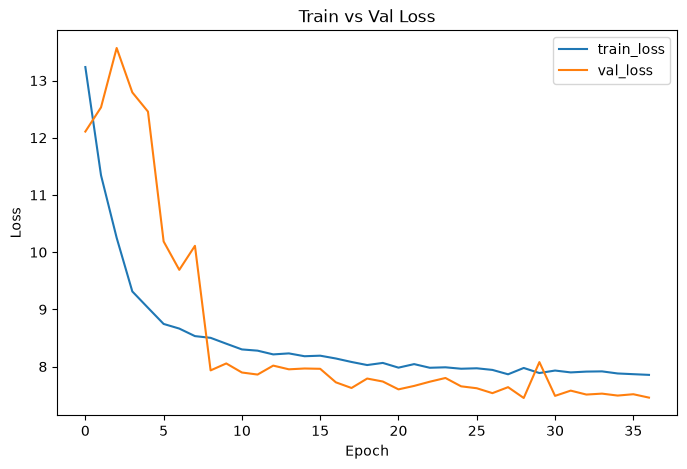

In [ ]:
# ========================= PLOT LOSS CURVES =========================
# Do this before concluding "it's overfitting" -- look at the shape, not
# just the final numbers. Steadily diverging train/val = overfitting.
# Noisy/jumpy val loss with a small val set (173 images here) can look
# scary without being a real overfitting signal.
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Val Loss')
plt.legend()
plt.show()

In [ ]:




# ========================= SINGLE IMAGE PREDICTION =========================
# Uses the same tf-based preprocessing as training (the original notebook's
# prediction cell used cv2, which was never imported -- would have crashed).
def prepare_single_image(img_path):
    image = preprocess_image(img_path)              # (H, W, 1), float32 0-1
    display_img = tf.squeeze(image, axis=-1).numpy() # for plotting
    input_tensor = tf.expand_dims(image, axis=0).numpy()
    return display_img, input_tensor

IMAGE_PATH = os.path.join(TEST_IMG_DIR, "75230801377_crop_0.png")  # change as needed

try:
    display_img, input_tensor = prepare_single_image(IMAGE_PATH)
    predictions = model.predict(input_tensor)

    if isinstance(predictions, dict):
        digits = [predictions[f'digit{i}'][0] for i in range(1, 6)]
    else:
        digits = [predictions[i][0] for i in range(5)]

    final_reading = "".join(str(np.argmax(d)) for d in digits)
    confidence_scores = [np.max(d) * 100 for d in digits]

    plt.figure(figsize=(6, 3))
    plt.imshow(display_img, cmap='gray')
    plt.title(f"Prediction: {final_reading}\nAvg Confidence: {np.mean(confidence_scores):.1f}%",
              fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.savefig('/mnt/user-data/outputs/prediction_example.png', dpi=120, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Prediction Error: {e}")



In [ ]:
# ========================= SAVE MODEL =========================
model.save("captcha_model_final.keras")
print("Training completed and model saved.")